In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array


In [2]:
import pathlib
data_dir=pathlib.Path('/content/drive/MyDrive/Datasets/Drone')

In [3]:
import os
c=[]
n=[]
for i in os.listdir(data_dir):
  dir = pathlib.Path('/content/drive/MyDrive/Datasets/Drone_Balanced/'+ i)
  c.append(i)
  n.append(len(list(dir.glob("*.jpg"))))
  print(i, len(list(dir.glob("*.jpg"))))

Dusty 190
Snow-Covered 190
Physical-Damage 190
Clean 189
Electrical-damage 186
Bird-drop 190


In [ ]:
c=[0,1,2,3,4,5]

In [ ]:
plt.bar(c,n)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)


In [ ]:
output_dir = pathlib.Path('/content/drive/MyDrive/Datasets/Drone_Balanced')


In [ ]:
class_counts = {}
for cls in os.listdir(data_dir):
    cls_path = data_dir / cls
    if cls_path.is_dir():
        imgs = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png'))
        class_counts[cls] = len(imgs)

max_count = max(class_counts.values())
print(f'Target per class: {max_count}\n')

for cls, count in class_counts.items():
    src_dir = data_dir / cls
    dst_dir = output_dir / cls
    dst_dir.mkdir(parents=True, exist_ok=True)

    images = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))

    # Copy originals
    for img_path in images:
        import shutil
        shutil.copy(img_path, dst_dir / img_path.name)

    needed = max_count - count
    if needed == 0:
        print(f'{cls}: already at max ({count}), copied as-is')
        continue

    print(f'{cls}: generating {needed} augmented images...')
    aug_idx = 0
    while aug_idx < needed:
        img_path = images[aug_idx % len(images)]
        img = load_img(img_path, target_size=(224, 224))
        x   = img_to_array(img)
        x   = x.reshape((1,) + x.shape)

        for batch in datagen.flow(
            x,
            batch_size=1,
            save_to_dir=dst_dir,
            save_prefix=f'aug_{aug_idx:05d}',
            save_format='jpg'
        ):
            aug_idx += 1
            break
        if aug_idx >= needed:
            break

    print(f'  → Done: {count} original + {needed} augmented = {max_count} total')

print('\nBalanced dataset saved to:', output_dir)

In [4]:
data_dir = pathlib.Path("/content/drive/MyDrive/Datasets/Drone_Balanced")

In [5]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

1135


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(224, 224),
  batch_size=32)

Found 1140 files belonging to 6 classes.
Using 912 files for training.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(224, 224),
  batch_size=32)

Found 1140 files belonging to 6 classes.
Using 228 files for validation.


In [8]:
class_names=train_ds.class_names
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

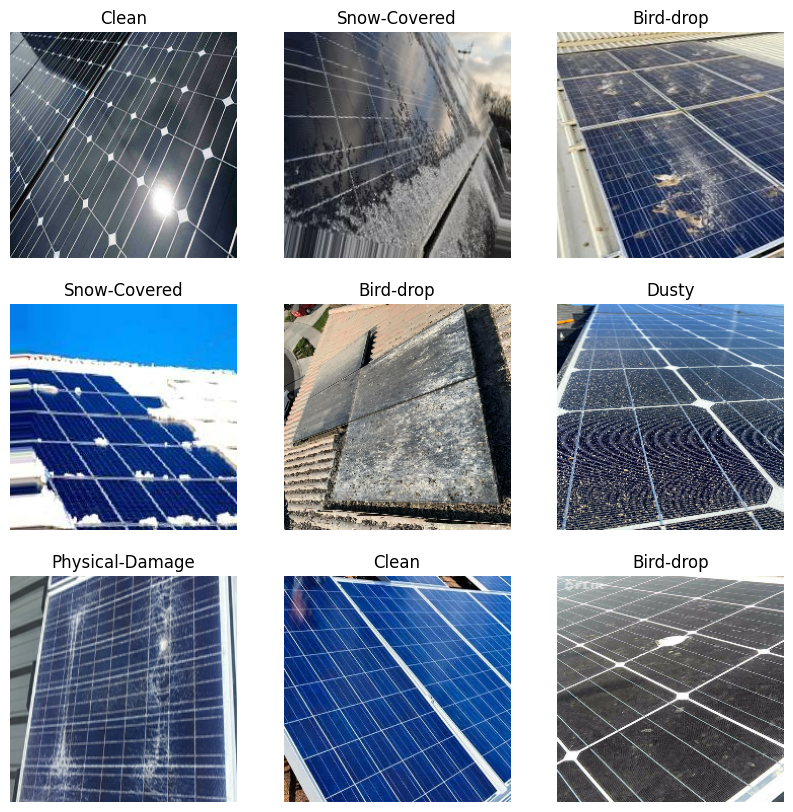

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
img_height=224
img_width=224

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
num_classes = len(class_names)

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3)
)

base_model.trainable = False

model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),   # add this
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,478 (27.35 MB)

 Trainable params: 131,974 (515.52 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

epochs = 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.3159 - loss: 2.0209 - val_accuracy: 0.6711 - val_loss: 0.9022
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.6407 - loss: 0.9527 - val_accuracy: 0.7939 - val_loss: 0.7454
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.7450 - loss: 0.7284 - val_accuracy: 0.8202 - val_loss: 0.5882
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.7920 - loss: 0.5540 - val_accuracy: 0.8465 - val_loss: 0.5302
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.8254 - loss: 0.5033 - val_accuracy: 0.8596 - val_loss: 0.4943
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8530 - loss: 0.4411 - val_accuracy: 0.8421 - val_loss: 0.4929
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.8766 - loss: 0.3969 - val_accuracy: 0.8465 - val_loss: 0.4692
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.8729 - loss: 0.3547 - val_accuracy: 0.85

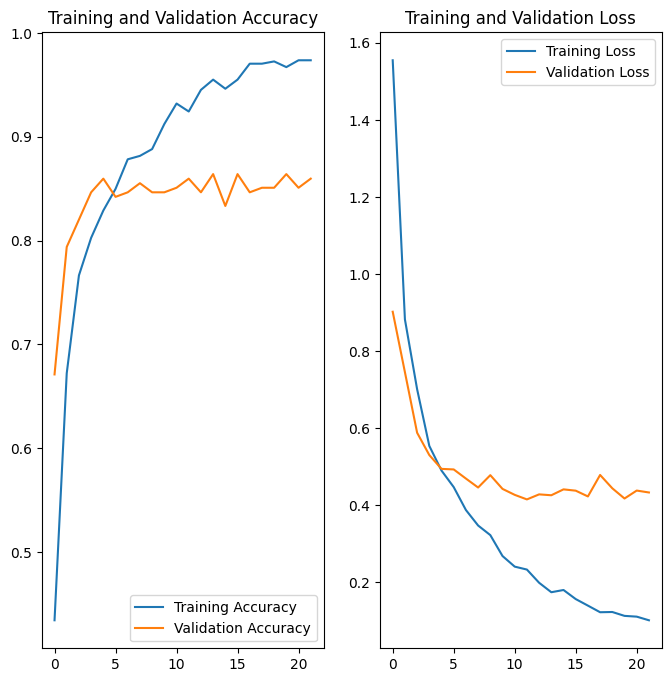

In [44]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(history.history['accuracy']))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [22]:
img_path ='/content/drive/MyDrive/Datasets/Drone/Clean/Clean (1).jpeg'
img = tf.keras.utils.load_img(
    img_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
This image most likely belongs to Clean with a 33.77 percent confidence.


In [ ]:
model.save('model_densenet.h5')